In [3]:
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
# Recommended for any plot for a science publication.
# Some paper submision systems (e.g. MNRAS) requires next lines to be done for
# your pictures.
# Read more about font types: https://en.wikipedia.org/wiki/PostScript_fonts
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['pdf.fonttype'] = 42
# plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight']= 'normal'

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False


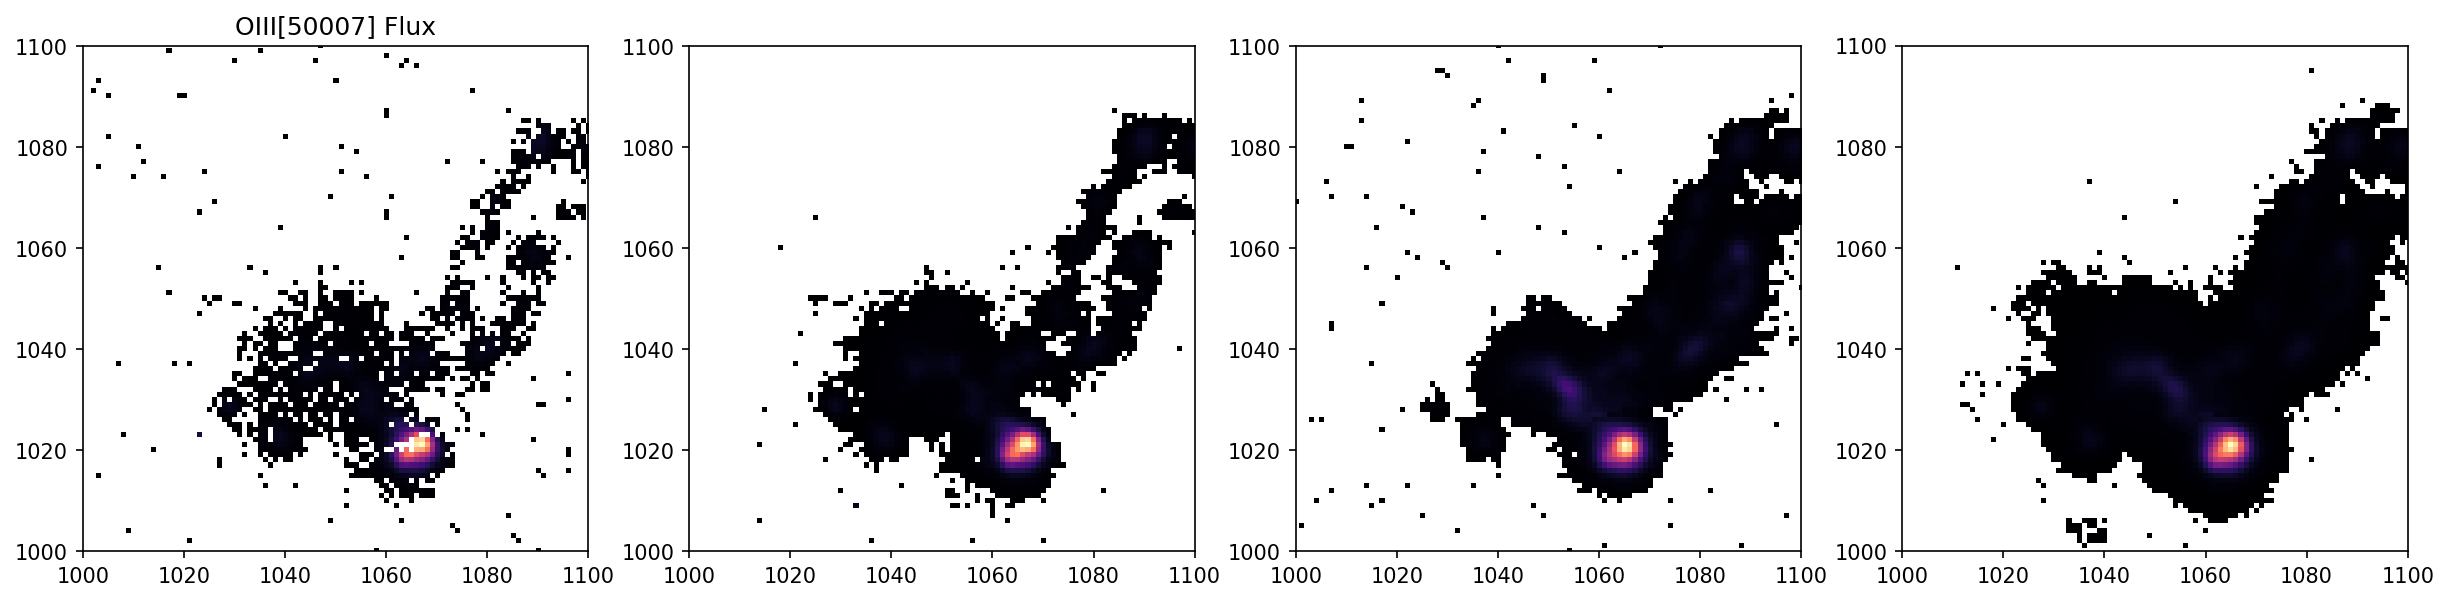

<Figure size 640x480 with 0 Axes>

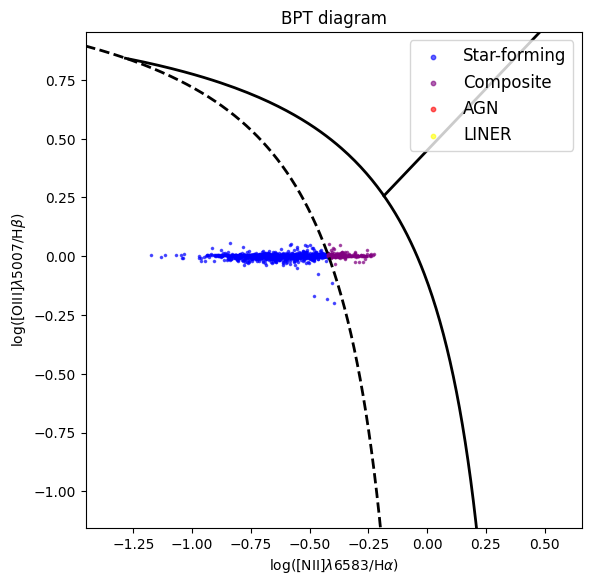

In [14]:
from astropy.io import fits
import numpy as np
import astropy.io.fits as fits
import orb
import orb.utils.graph as graph
import matplotlib.pyplot as plt
from orcs.process import SpectralCube
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable


# to be changed depending on where you save IIZw96 data
data_path = '/Users/leianydeoleo/Desktop/IIZw96/'

cube_SN3 = SpectralCube(data_path + 'SN3.hdf5')

map_ha, map_ha_hdr = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96/Halpha/flux /IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits', return_header=True)
map_ha_err = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96/Halpha/flux /IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')
map_ha[map_ha<0] = np.nan
ha_line_snr = map_ha / map_ha_err
map_ha[ha_line_snr<=3] = np.nan

map_nii = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux.fits')
map_nii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux-err.fits')
map_nii[map_nii<0] = np.nan
nii_line_snr = map_nii / map_nii_err
map_nii[nii_line_snr<=3] = np.nan

map_hb = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/fits/IIZw96_SN2.LineMaps.map.4861.1x1.flux.fits')
map_hb_err = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96/Hbetha/flux/IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits')
map_hb[map_hb<0] = np.nan
hb_line_snr = map_hb / map_hb_err
map_hb[hb_line_snr<=3] = np.nan

map_oiii = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/fits/IIZw96_SN2.LineMaps.map.5007.1x1.flux.fits')
map_oiii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/fits/IIZw96_SN2.LineMaps.map.5007.1x1.flux-err.fits')
map_oiii[map_oiii<0] = np.nan
oiii_line_snr = map_oiii / map_oiii_err
map_oiii[oiii_line_snr<=3] = np.nan

nii_ha_ratio_map = map_nii / map_ha
nii_ha_ratio_map[(map_nii <= 0) | (map_ha <= 0)] = np.nan

oiii_hb_ratio_map = map_oiii / map_hb
oiii_hb_ratio_map[(map_oiii <= 0) | (map_hb <= 0)] = np.nan

nii_ha_ratio_map[nii_ha_ratio_map <= 0] = np.nan
oiii_hb_ratio_map[oiii_hb_ratio_map <= 0] = np.nan

fig, ax = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(20, 5),   # width x height in inches
    dpi=150
)

for ax_ in [ax[0], ax[1], ax[2], ax[3]]:
    ax_.set_xlim(1000, 1100)
    ax_.set_ylim(1000, 1100)
ax[0].imshow(map_oiii.T, origin='lower', cmap='magma')
ax[1].imshow(map_hb.T, origin='lower', cmap='magma')
ax[2].imshow(map_nii.T, origin='lower', cmap='magma')
ax[3].imshow(map_ha.T, origin='lower', cmap='magma')

ax[0].set_title('OIII[50007] Flux')
plt.show()

position_ID7  = SkyCoord(314.351423, 17.127521, unit='deg')
position_ID8  = SkyCoord(314.351552, 17.127566, unit='deg')
position_ID11 = SkyCoord(314.351972, 17.127732, unit='deg')

def classify_first_bpt(oiii_h_beta_ratio, nii_h_alpha_ratio):
        r"""
        Function for classification with BPT diagrams following
         Kewley et al. 2006 doi:10.1111/j.1365-2966.2006.10859.x using equation in Sect. 3.1
         and Schawinski et al. 2007 doi:10.1111/j.1365-2966.2007.12487.x Using equation 1 in Sect. 2.5.1
        :param oiii_h_beta_ratio: log-value of emission line ratio [OIII]5008 / H$\beta$4863
        :type oiii_h_beta_ratio: array-like
        :param nii_h_alpha_ratio: log-value of emission line ratio [NII]6550 / H$\alpha$6565
        :type nii_h_alpha_ratio: array-like
        :return variable specifying the BPT classification
        :rtype: str
        """

        if oiii_h_beta_ratio.ndim > 1:
            classification = np.zeros(oiii_h_beta_ratio.shape, dtype='S6')
        else:
            classification = np.zeros(len(oiii_h_beta_ratio), dtype='S6')

        # sf
        # eq. (1) (Kewley et al. 2006)
        mask_sf = (oiii_h_beta_ratio < 0.61 / (nii_h_alpha_ratio - 0.05) + 1.3) & (nii_h_alpha_ratio < - 0.1)
        classification[mask_sf] = 'sf'

        # composite
        # eq. (4) and (5) (Kewley et al. 2006)
        mask_comp = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) |
                      ((nii_h_alpha_ratio > - 0.1) & (nii_h_alpha_ratio < 0.4))) &
                     (oiii_h_beta_ratio < (0.61 / (nii_h_alpha_ratio - 0.47) + 1.19)))
        classification[mask_comp] = 'comp'

        # agn
        # eq. (6) (Kewley et al. 2006) with limit of nii_h_alpha_ratio < - 1.2825 and eq. (1) (Schawinski et al. 2007)
        mask_agn = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) & (nii_h_alpha_ratio < - 1.2825)) |
                    ((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) & (nii_h_alpha_ratio > - 1.2825)) |
                    ((oiii_h_beta_ratio > 1.05 * nii_h_alpha_ratio + 0.45) & (nii_h_alpha_ratio > - 0.05)))
        classification[mask_agn] = 'agn'

        # liner
        # eq. (11) (Kewley et al. 2006) and eq. (1) (Schawinski et al. 2007)
        mask_liner = (((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) &
                       (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)) |
                      ((nii_h_alpha_ratio > 0.45) & (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)))
        classification[mask_liner] = 'liner'

        return classification

def save_first_BPT_classification():
    hdr = map_ha_hdr
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )

    classification_first_bpt = np.zeros(map_ha.shape, dtype='S20')
    classification_first_bpt = classify_first_bpt(log_oiii_hb_map, log_nii_ha_map )
    #for i in range(hdr['NAXIS2']):
    #for j in range(hdr['NAXIS1']):
     #        classification_first_bpt[i,j] = classify_first_bpt(log_oiii_hb_map[i,j], log_nii_ha_map [i,j])
     #        np.save('./classify_first_BPT_ID8_3arcsec.npy', classification_first_bpt)


def plot_BPT_diagram_2d_map_and_scatter_plot():
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )

    hdr = map_ha_hdr
    wcs = WCS(hdr)

    fig = plt.figure()

    #ax1 = fig.add_subplot( projection=cube_SN3.get_wcs())
    fig = plt.figure(figsize=(6, 6), dpi=100)






    cmap = colors.ListedColormap(['purple', 'green', 'orange', 'yellow'])
    bounds = [1, 2, 3, 4, 5]
    norm = colors.BoundaryNorm(bounds, cmap.N)




    ax2 = fig.add_subplot(111)

    ax2.set_title(r'BPT diagram')
    tt_1 = np.arange(0.01, 1.0, 0.001)
    ax2.plot(np.log10(tt_1), 0.61 / (np.log10(tt_1) - 0.05) + 1.3, 'k--', linewidth=2)

    tt_2 = np.arange(0.0521, 2.0, 0.01)
    ax2.plot(np.log10(tt_2), 0.61 / (np.log10(tt_2) - 0.47) + 1.19, 'k-', linewidth=2)

    tt_3 = np.arange(0.655, 9.0, 0.01)
    ax2.plot(np.log10(tt_3), 1.05 * np.log10(tt_3) + 0.45, 'k-', linewidth=2)

    ax2.set_aspect('equal', adjustable='box')
    ax2.set_box_aspect(1)



    ax2.set_xlabel(r'$\log([\mathrm{NII}]\lambda6583 / \mathrm{H}\alpha)$')
    ax2.set_ylabel(r'$\log([\mathrm{OIII}]\lambda5007 / \mathrm{H}\beta)$')


    ax2.scatter(
    log_nii_ha_map[class_first_bpt==1.5],
    log_oiii_hb_map[class_first_bpt==1.5],
    marker='.',
    c='b',
    s=10,
    alpha=0.6,
    label='Star-forming')

    ax2.scatter(
    log_nii_ha_map[class_first_bpt==2.5],
    log_oiii_hb_map[class_first_bpt==2.5],
    marker='.',
    c='purple',
    s=10,
    alpha=0.6,
    label='Composite')

    ax2.scatter(
    log_nii_ha_map[class_first_bpt==3.5],
    log_oiii_hb_map[class_first_bpt==3.5],
    marker='.',
    c='r',
    s=10,
    alpha=0.6,
    label='AGN')

    ax2.scatter(
    log_nii_ha_map[class_first_bpt==4.5],
    log_oiii_hb_map[class_first_bpt==4.5],
    marker='.',
    c='yellow',
    s=10,
    alpha=0.6,
    label='LINER')

    ax2.legend( loc='upper right',
    frameon=True,
    fontsize=12,
    markerscale=2)
    ax2.set_xlim(np.log10(0.1), np.log10(1.6))
    ax2.set_ylim(np.log10(0.07), np.log10(9))



    plt.tight_layout()
    plt.show()

    save_first_BPT_classification()

region_classification_first_BPT = np.load('./classify_first_BPT_ID8_3arcsec.npy')
class_first_bpt = np.zeros(region_classification_first_BPT.shape)
class_first_bpt[region_classification_first_BPT == b'sf'] = 1.5
class_first_bpt[region_classification_first_BPT == b'comp'] = 2.5
class_first_bpt[region_classification_first_BPT == b'agn'] = 3.5
class_first_bpt[region_classification_first_BPT == b'liner'] = 4.5

plot_BPT_diagram_2d_map_and_scatter_plot()

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False
unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_51656/2620527556.py:52: RuntimeWarning: divide by zero encountered in divide
  oiii_hb_ratio_map = map_oiii / map_hb.T

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_51656/2620527556.py:52: RuntimeWarning: invalid value encountered in divide
  oiii_hb_ratio_map = map_oiii / map_hb.T



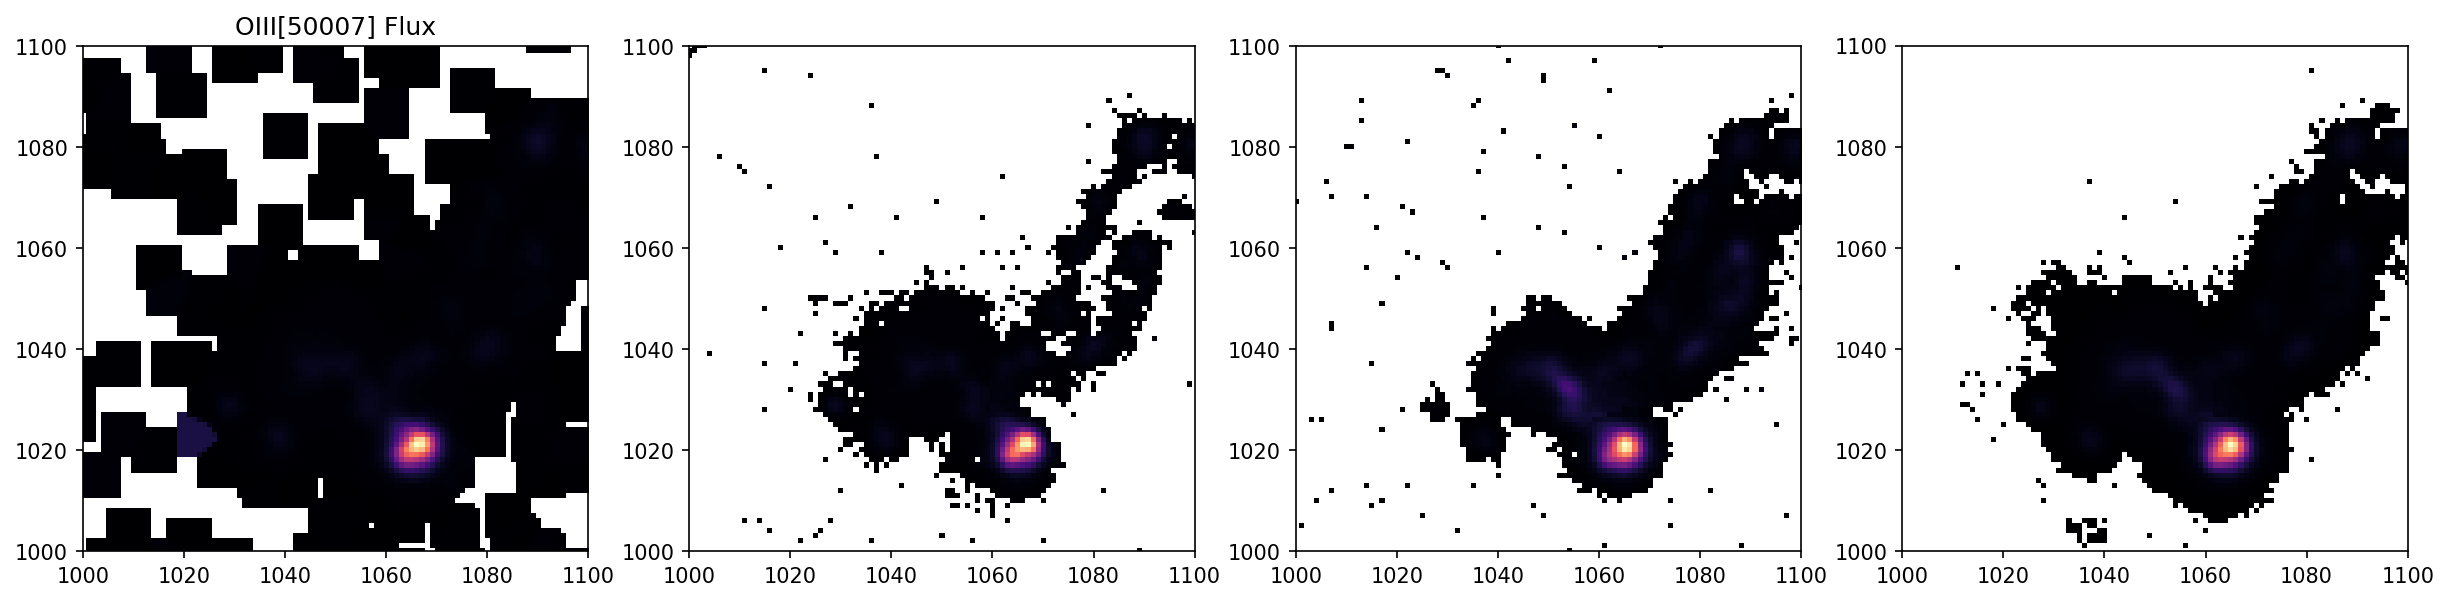

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_51656/2620527556.py:144: RuntimeWarning: divide by zero encountered in divide
  oiii_hb_ratio_map = map_oiii / map_hb.T

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_51656/2620527556.py:144: RuntimeWarning: invalid value encountered in divide
  oiii_hb_ratio_map = map_oiii / map_hb.T



<Figure size 640x480 with 0 Axes>

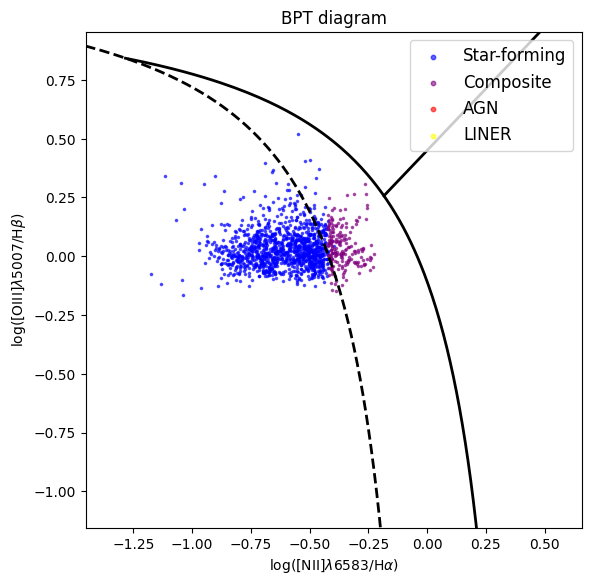

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_51656/2620527556.py:129: RuntimeWarning: divide by zero encountered in divide
  oiii_hb_ratio_map = map_oiii / map_hb.T

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_51656/2620527556.py:129: RuntimeWarning: invalid value encountered in divide
  oiii_hb_ratio_map = map_oiii / map_hb.T



In [11]:
from astropy.io import fits
import numpy as np
import astropy.io.fits as fits
import orb
import orb.utils.graph as graph
import matplotlib.pyplot as plt
from orcs.process import SpectralCube
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable


# to be changed depending on where you save IIZw96 data
data_path = '/Users/leianydeoleo/Desktop/IIZw96/'

cube_SN3 = SpectralCube(data_path + 'SN3.hdf5')

map_ha, map_ha_hdr = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96/Halpha/flux /IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits', return_header=True)
map_ha_err = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96/Halpha/flux /IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')
map_ha[map_ha<0] = np.nan
ha_line_snr = map_ha / map_ha_err
map_ha[ha_line_snr<=3] = np.nan

map_nii = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux.fits')
map_nii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux-err.fits')
map_nii[map_nii<0] = np.nan
nii_line_snr = map_nii / map_nii_err
map_nii[nii_line_snr<=3] = np.nan

map_hb = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/hbeta_smoothed_SN2.fits')
map_hb_err = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96/Hbetha/flux/IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits')
map_hb.T[map_hb.T<0] = np.nan
hb_line_snr = map_hb.T / map_hb_err
map_hb.T[hb_line_snr<=3] = np.nan

map_oiii = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/fits/IIZw96_SN2.LineMaps.map.5007.1x1.flux.fits')
map_oiii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/fits/IIZw96_SN2.LineMaps.map.5007.1x1.flux-err.fits')
map_oiii[map_oiii<0] = np.nan
oiii_line_snr = map_oiii / map_oiii_err
map_oiii[oiii_line_snr<=3] = np.nan

from astropy.convolution import convolve, Gaussian2DKernel

kernel = Gaussian2DKernel(1)

map_oiii = convolve(map_oiii, kernel, nan_treatment='interpolate')

nii_ha_ratio_map = map_nii / map_ha
nii_ha_ratio_map[(map_nii <= 0) | (map_ha <= 0)] = np.nan

oiii_hb_ratio_map = map_oiii / map_hb.T
oiii_hb_ratio_map[(map_oiii <= 0) | (map_hb.T <= 0)] = np.nan

nii_ha_ratio_map[nii_ha_ratio_map <= 0] = np.nan
oiii_hb_ratio_map[oiii_hb_ratio_map <= 0] = np.nan

fig, ax = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(20, 5),   # width x height in inches
    dpi=150
)

for ax_ in [ax[0], ax[1], ax[2], ax[3]]:
    ax_.set_xlim(1000, 1100)
    ax_.set_ylim(1000, 1100)
ax[0].imshow(map_oiii.T, origin='lower', cmap='magma')
ax[1].imshow(map_hb, origin='lower', cmap='magma')
ax[2].imshow(map_nii.T, origin='lower', cmap='magma')
ax[3].imshow(map_ha.T, origin='lower', cmap='magma')

ax[0].set_title('OIII[50007] Flux')
plt.show()

position_ID7  = SkyCoord(314.351423, 17.127521, unit='deg')
position_ID8  = SkyCoord(314.351552, 17.127566, unit='deg')
position_ID11 = SkyCoord(314.351972, 17.127732, unit='deg')

def classify_first_bpt(oiii_h_beta_ratio, nii_h_alpha_ratio):
        r"""
        Function for classification with BPT diagrams following
         Kewley et al. 2006 doi:10.1111/j.1365-2966.2006.10859.x using equation in Sect. 3.1
         and Schawinski et al. 2007 doi:10.1111/j.1365-2966.2007.12487.x Using equation 1 in Sect. 2.5.1
        :param oiii_h_beta_ratio: log-value of emission line ratio [OIII]5008 / H$\beta$4863
        :type oiii_h_beta_ratio: array-like
        :param nii_h_alpha_ratio: log-value of emission line ratio [NII]6550 / H$\alpha$6565
        :type nii_h_alpha_ratio: array-like
        :return variable specifying the BPT classification
        :rtype: str
        """

        if oiii_h_beta_ratio.ndim > 1:
            classification = np.zeros(oiii_h_beta_ratio.shape, dtype='S6')
        else:
            classification = np.zeros(len(oiii_h_beta_ratio), dtype='S6')

        # sf
        # eq. (1) (Kewley et al. 2006)
        mask_sf = (oiii_h_beta_ratio < 0.61 / (nii_h_alpha_ratio - 0.05) + 1.3) & (nii_h_alpha_ratio < - 0.1)
        classification[mask_sf] = 'sf'

        # composite
        # eq. (4) and (5) (Kewley et al. 2006)
        mask_comp = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) |
                      ((nii_h_alpha_ratio > - 0.1) & (nii_h_alpha_ratio < 0.4))) &
                     (oiii_h_beta_ratio < (0.61 / (nii_h_alpha_ratio - 0.47) + 1.19)))
        classification[mask_comp] = 'comp'

        # agn
        # eq. (6) (Kewley et al. 2006) with limit of nii_h_alpha_ratio < - 1.2825 and eq. (1) (Schawinski et al. 2007)
        mask_agn = (((oiii_h_beta_ratio > (0.61 / (nii_h_alpha_ratio - 0.05) + 1.3)) & (nii_h_alpha_ratio < - 1.2825)) |
                    ((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) & (nii_h_alpha_ratio > - 1.2825)) |
                    ((oiii_h_beta_ratio > 1.05 * nii_h_alpha_ratio + 0.45) & (nii_h_alpha_ratio > - 0.05)))
        classification[mask_agn] = 'agn'

        # liner
        # eq. (11) (Kewley et al. 2006) and eq. (1) (Schawinski et al. 2007)
        mask_liner = (((oiii_h_beta_ratio > 0.61 / (nii_h_alpha_ratio - 0.47) + 1.19) &
                       (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)) |
                      ((nii_h_alpha_ratio > 0.45) & (oiii_h_beta_ratio < 1.05 * nii_h_alpha_ratio + 0.45)))
        classification[mask_liner] = 'liner'

        return classification

def save_first_BPT_classification():
    hdr = map_ha_hdr
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb.T

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )

    classification_first_bpt = np.zeros(map_ha.shape, dtype='S20')
    classification_first_bpt = classify_first_bpt(log_oiii_hb_map, log_nii_ha_map )
    #for i in range(hdr['NAXIS2']):
    #for j in range(hdr['NAXIS1']):
     #        classification_first_bpt[i,j] = classify_first_bpt(log_oiii_hb_map[i,j], log_nii_ha_map [i,j])
     #        np.save('./classify_first_BPT_ID8_3arcsec.npy', classification_first_bpt)


def plot_BPT_diagram_2d_map_and_scatter_plot():
    nii_ha_ratio_map = map_nii / map_ha
    oiii_hb_ratio_map = map_oiii / map_hb.T

    log_nii_ha_map = np.log10( nii_ha_ratio_map )
    log_oiii_hb_map = np.log10( oiii_hb_ratio_map )

    hdr = map_ha_hdr
    wcs = WCS(hdr)

    fig = plt.figure()

    #ax1 = fig.add_subplot( projection=cube_SN3.get_wcs())
    fig = plt.figure(figsize=(6, 6), dpi=100)






    cmap = colors.ListedColormap(['purple', 'green', 'orange', 'yellow'])
    bounds = [1, 2, 3, 4, 5]
    norm = colors.BoundaryNorm(bounds, cmap.N)




    ax2 = fig.add_subplot(111)

    ax2.set_title(r'BPT diagram')
    tt_1 = np.arange(0.01, 1.0, 0.001)
    ax2.plot(np.log10(tt_1), 0.61 / (np.log10(tt_1) - 0.05) + 1.3, 'k--', linewidth=2)

    tt_2 = np.arange(0.0521, 2.0, 0.01)
    ax2.plot(np.log10(tt_2), 0.61 / (np.log10(tt_2) - 0.47) + 1.19, 'k-', linewidth=2)

    tt_3 = np.arange(0.655, 9.0, 0.01)
    ax2.plot(np.log10(tt_3), 1.05 * np.log10(tt_3) + 0.45, 'k-', linewidth=2)

    ax2.set_aspect('equal', adjustable='box')
    ax2.set_box_aspect(1)



    ax2.set_xlabel(r'$\log([\mathrm{NII}]\lambda6583 / \mathrm{H}\alpha)$')
    ax2.set_ylabel(r'$\log([\mathrm{OIII}]\lambda5007 / \mathrm{H}\beta)$')


    ax2.scatter(
    log_nii_ha_map[class_first_bpt==1.5],
    log_oiii_hb_map[class_first_bpt==1.5],
    marker='.',
    c='b',
    s=10,
    alpha=0.6,
    label='Star-forming')

    ax2.scatter(
    log_nii_ha_map[class_first_bpt==2.5],
    log_oiii_hb_map[class_first_bpt==2.5],
    marker='.',
    c='purple',
    s=10,
    alpha=0.6,
    label='Composite')

    ax2.scatter(
    log_nii_ha_map[class_first_bpt==3.5],
    log_oiii_hb_map[class_first_bpt==3.5],
    marker='.',
    c='r',
    s=10,
    alpha=0.6,
    label='AGN')

    ax2.scatter(
    log_nii_ha_map[class_first_bpt==4.5],
    log_oiii_hb_map[class_first_bpt==4.5],
    marker='.',
    c='yellow',
    s=10,
    alpha=0.6,
    label='LINER')

    ax2.legend( loc='upper right',
    frameon=True,
    fontsize=12,
    markerscale=2)
    ax2.set_xlim(np.log10(0.1), np.log10(1.6))
    ax2.set_ylim(np.log10(0.07), np.log10(9))



    plt.tight_layout()
    plt.show()

    save_first_BPT_classification()

region_classification_first_BPT = np.load('./classify_first_BPT_ID8_3arcsec.npy')
class_first_bpt = np.zeros(region_classification_first_BPT.shape)
class_first_bpt[region_classification_first_BPT == b'sf'] = 1.5
class_first_bpt[region_classification_first_BPT == b'comp'] = 2.5
class_first_bpt[region_classification_first_BPT == b'agn'] = 3.5
class_first_bpt[region_classification_first_BPT == b'liner'] = 4.5

plot_BPT_diagram_2d_map_and_scatter_plot()

<Figure size 640x480 with 0 Axes>

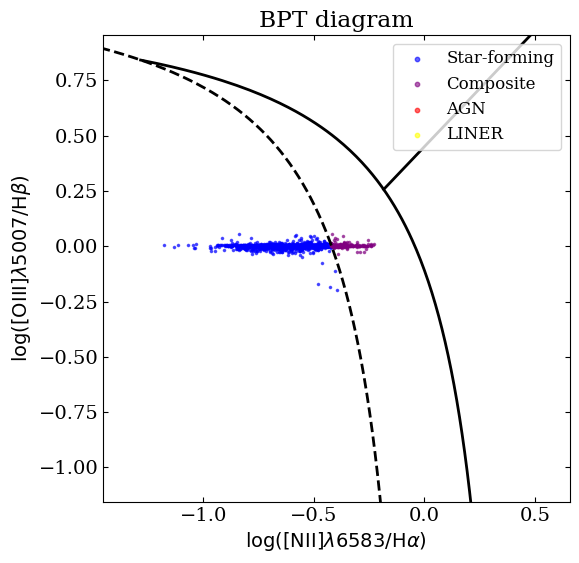

In [43]:
save_first_BPT_classification()

region_classification_first_BPT = np.load('./classify_first_BPT_ID8_3arcsec.npy')
class_first_bpt = np.zeros(region_classification_first_BPT.shape)
class_first_bpt[region_classification_first_BPT == b'sf'] = 1.5
class_first_bpt[region_classification_first_BPT == b'comp'] = 2.5
class_first_bpt[region_classification_first_BPT == b'agn'] = 3.5
class_first_bpt[region_classification_first_BPT == b'liner'] = 4.5

plot_BPT_diagram_2d_map_and_scatter_plot()

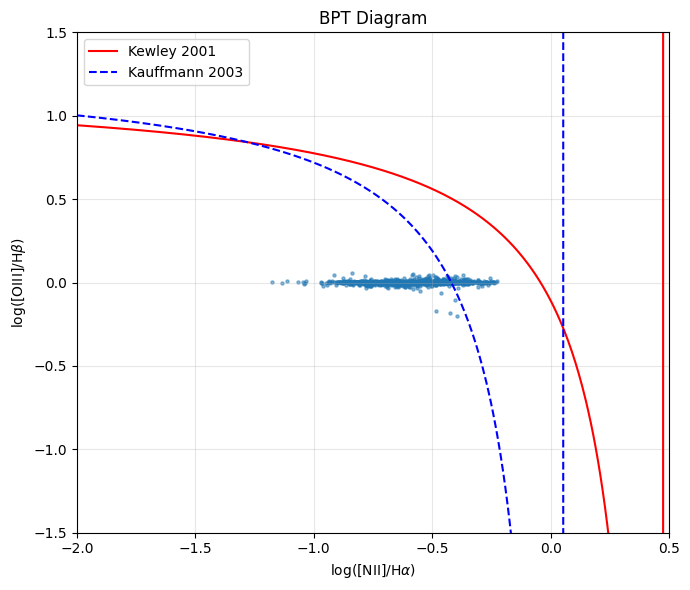

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import orb.utils.io

# --- Load maps ---
map_ha = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96/Halpha/flux /IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits')
map_ha_err = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96/Halpha/flux /IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits')

map_hb = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/hbeta_smoothed_SN2.fits')
map_hb_err = orb.utils.io.read_fits('/Users/leianydeoleo/Downloads/IIZW96/Hbetha/flux/IIZw96_SN2.LineMaps.map.4861.1x1.flux-err.fits')

map_oiii = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/fits/IIZw96_SN2.LineMaps.map.5007.1x1.flux.fits')
map_oiii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZW96/fits/IIZw96_SN2.LineMaps.map.5007.1x1.flux-err.fits')

map_nii = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux.fits')
map_nii_err = orb.utils.io.read_fits('/Users/leianydeoleo/Desktop/IIZw96/MAPS/IIZw96_SN3.LineMaps.map.6583.1x1.flux-err.fits')

from astropy.convolution import convolve, Gaussian2DKernel

kernel = Gaussian2DKernel(1)

map_oiii = convolve(map_oiii, kernel, nan_treatment='interpolate')

# --- Mask negative flux ---
for m in [map_ha, map_hb.T, map_oiii, map_nii]:
    m[m <= 0] = np.nan

# --- Compute SNR ---
snr_ha = map_ha / map_ha_err
snr_hb = map_hb.T / map_hb_err
snr_oiii = map_oiii / map_oiii_err
snr_nii = map_nii / map_nii_err

# --- Apply SNR cut (>=3) ---
#mask = (snr_ha >= 3) & (snr_hb >= 3) & (snr_oiii >= 3) & (snr_nii >= 3)

# --- Compute line ratios ---
log_oiii_hb = np.full_like(map_ha, np.nan)
log_nii_ha = np.full_like(map_ha, np.nan)

log_oiii_hb[mask] = np.log10(map_oiii[mask] / map_hb.T[mask])
log_nii_ha[mask] = np.log10(map_nii[mask] / map_ha[mask])

# --- Flatten & remove NaNs ---
#x = log_nii_ha.flatten()
#y = log_oiii_hb.flatten()

#valid = (~np.isnan(x)) & (~np.isnan(y))
#x = x[valid]
#y = y[valid]

# --- BPT curves ---
x_line = np.linspace(-2.0, 0.5, 500)

# Kewley 2001
kewley = 0.61 / (x_line - 0.47) + 1.19

# Kauffmann 2003
kauffmann = 0.61 / (x_line - 0.05) + 1.3

# --- Plot ---
plt.figure(figsize=(7,6))

plt.scatter(x, y, s=5, alpha=0.5)

plt.plot(x_line, kewley, 'r-', label='Kewley 2001')
plt.plot(x_line, kauffmann, 'b--', label='Kauffmann 2003')

plt.xlabel(r'log([NII]/H$\alpha$)')
plt.ylabel(r'log([OIII]/H$\beta$)')
plt.title('BPT Diagram')

plt.legend()
plt.grid(alpha=0.3)

plt.xlim(-2, 0.5)
plt.ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

In [7]:
print("Median OIII/Hb:", np.nanmedian(map_oiii / map_hb.T))
print("Median NII/Ha:", np.nanmedian(map_nii / map_ha))

unknown|WARNING| /var/folders/z2/cyrryhq935s6www7t5tzs4nr0000gn/T/ipykernel_51656/4005832482.py:1: RuntimeWarning: divide by zero encountered in divide
  print("Median OIII/Hb:", np.nanmedian(map_oiii / map_hb.T))



Median OIII/Hb: 1.0047319484623547
Median NII/Ha: 0.30597762871441975
